### Pdf to images

In [1]:
from pdf2image import convert_from_path
import os

POPPLER_PATH = r"C:\poppler\Library\bin"

def convert_pdfs_to_images(input_folder, output_folder):
    os.makedirs(output_folder, exist_ok=True)

    for file in os.listdir(input_folder):
        if file.endswith(".pdf"):
            pdf_path = os.path.join(input_folder, file)

            pages = convert_from_path(
                pdf_path,
                dpi=300,
                poppler_path=POPPLER_PATH
            )

            for i, page in enumerate(pages):
                image_name = f"{file[:-4]}.png"
                page.save(os.path.join(output_folder, image_name), "PNG")

convert_pdfs_to_images("C:/Users/tirth/Desktop/Practicals/DL(6thsem)/collected_dataset/genuine", "C:/Users/tirth/Desktop/Practicals/DL(6thsem)/collected_dataset/genuine")
convert_pdfs_to_images("C:/Users/tirth/Desktop/Practicals/DL(6thsem)/collected_dataset/forged", "C:/Users/tirth/Desktop/Practicals/DL(6thsem)/collected_dataset/forged")

print("PDF to Images done!")

PDF to Images done!


### Genuine signatures' cropping

In [2]:
import cv2
import numpy as np
import os

# ==============================
# PATHS
# ==============================
input_folder = "C:/Users/tirth/Desktop/Practicals/DL(6thsem)/collected_dataset/genuine"
output_folder = "C:/Users/tirth/Desktop/Practicals/DL(6thsem)/collected_dataset/cropped/genuine"

os.makedirs(output_folder, exist_ok=True)

image_files = [f for f in os.listdir(input_folder)
               if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

# ==============================
# PROCESS EACH IMAGE
# ==============================
for file_name in image_files:

    print(f"\nProcessing: {file_name}")

    img = cv2.imread(os.path.join(input_folder, file_name))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    H, W = gray.shape

    rows = 3
    cols = 4

    cell_h = H // rows
    cell_w = W // cols

    count = 0
    base_name = os.path.splitext(file_name)[0]

    for i in range(rows):
        for j in range(cols):

            y1 = i * cell_h
            y2 = (i + 1) * cell_h
            x1 = j * cell_w
            x2 = (j + 1) * cell_w

            cell = gray[y1:y2, x1:x2]

            # ==============================
            # REMOVE GRID BORDER (VERY IMPORTANT)
            # ==============================
            margin = 10   # remove table lines safely
            h, w = cell.shape

            cell = cell[margin:h-margin, margin:w-margin]

            # ==============================
            # SIGNATURE CROP (tight)
            # ==============================
            _, thresh = cv2.threshold(cell, 150, 255, cv2.THRESH_BINARY_INV)

            coords = np.column_stack(np.where(thresh > 0))

            if coords.size > 0:
                y_min, x_min = coords.min(axis=0)
                y_max, x_max = coords.max(axis=0)

                pad = 5

                y_min = max(0, y_min - pad)
                x_min = max(0, x_min - pad)
                y_max = min(cell.shape[0], y_max + pad)
                x_max = min(cell.shape[1], x_max + pad)

                sign = cell[y_min:y_max, x_min:x_max]
            else:
                sign = cell

            # ==============================
            # FINAL CLEAN PADDING
            # ==============================
            sign = cv2.copyMakeBorder(
                sign, 10,10,10,10,
                cv2.BORDER_CONSTANT, value=255
            )

            # SAVE
            cv2.imwrite(
                os.path.join(output_folder,
                f"{base_name}_{count}.png"),
                sign
            )

            count += 1

    print(f"EXACTLY {count} signatures extracted")


Processing: Genuine_p1.png
EXACTLY 12 signatures extracted

Processing: Genuine_p10.png
EXACTLY 12 signatures extracted

Processing: Genuine_p11.png
EXACTLY 12 signatures extracted

Processing: Genuine_p12.png
EXACTLY 12 signatures extracted

Processing: Genuine_p13.png
EXACTLY 12 signatures extracted

Processing: Genuine_p14.png
EXACTLY 12 signatures extracted

Processing: Genuine_p15.png
EXACTLY 12 signatures extracted

Processing: Genuine_p16.png
EXACTLY 12 signatures extracted

Processing: Genuine_p17.png
EXACTLY 12 signatures extracted

Processing: Genuine_p18.png
EXACTLY 12 signatures extracted

Processing: Genuine_p19.png
EXACTLY 12 signatures extracted

Processing: Genuine_p2.png
EXACTLY 12 signatures extracted

Processing: Genuine_p20.png
EXACTLY 12 signatures extracted

Processing: Genuine_p21.png
EXACTLY 12 signatures extracted

Processing: Genuine_p22.png
EXACTLY 12 signatures extracted

Processing: Genuine_p23.png
EXACTLY 12 signatures extracted

Processing: Genuine_p3.pn

### Forged signatures' cropping

In [3]:
import cv2
import numpy as np
import os

# ==============================
# PATHS
# ==============================
input_folder = "C:/Users/tirth/Desktop/Practicals/DL(6thsem)/collected_dataset/forged"
output_folder = "C:/Users/tirth/Desktop/Practicals/DL(6thsem)/collected_dataset/cropped/forged"

os.makedirs(output_folder, exist_ok=True)

image_files = [f for f in os.listdir(input_folder)
               if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

# ==============================
# PROCESS EACH IMAGE
# ==============================
for file_name in image_files:

    print(f"\nProcessing: {file_name}")

    img = cv2.imread(os.path.join(input_folder, file_name))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    H, W = gray.shape

    rows = 3
    cols = 4

    cell_h = H // rows
    cell_w = W // cols

    count = 0
    base_name = os.path.splitext(file_name)[0]

    for i in range(rows):
        for j in range(cols):

            y1 = i * cell_h
            y2 = (i + 1) * cell_h
            x1 = j * cell_w
            x2 = (j + 1) * cell_w

            cell = gray[y1:y2, x1:x2]

            # ==============================
            # REMOVE GRID BORDER (VERY IMPORTANT)
            # ==============================
            margin = 10   # remove table lines safely
            h, w = cell.shape

            cell = cell[margin:h-margin, margin:w-margin]

            # ==============================
            # SIGNATURE CROP (tight)
            # ==============================
            _, thresh = cv2.threshold(cell, 150, 255, cv2.THRESH_BINARY_INV)

            coords = np.column_stack(np.where(thresh > 0))

            if coords.size > 0:
                y_min, x_min = coords.min(axis=0)
                y_max, x_max = coords.max(axis=0)

                pad = 5

                y_min = max(0, y_min - pad)
                x_min = max(0, x_min - pad)
                y_max = min(cell.shape[0], y_max + pad)
                x_max = min(cell.shape[1], x_max + pad)

                sign = cell[y_min:y_max, x_min:x_max]
            else:
                sign = cell

            # ==============================
            # FINAL CLEAN PADDING
            # ==============================
            sign = cv2.copyMakeBorder(
                sign, 10,10,10,10,
                cv2.BORDER_CONSTANT, value=255
            )

            # SAVE
            cv2.imwrite(
                os.path.join(output_folder,
                f"{base_name}_{count}.png"),
                sign
            )

            count += 1

    print(f"EXACTLY {count} signatures extracted")


Processing: Forged_p1.png
EXACTLY 12 signatures extracted

Processing: Forged_p10.png
EXACTLY 12 signatures extracted

Processing: Forged_p11.png
EXACTLY 12 signatures extracted

Processing: Forged_p12.png
EXACTLY 12 signatures extracted

Processing: Forged_p13.png
EXACTLY 12 signatures extracted

Processing: Forged_p14.png
EXACTLY 12 signatures extracted

Processing: Forged_p15.png
EXACTLY 12 signatures extracted

Processing: Forged_p16.png
EXACTLY 12 signatures extracted

Processing: Forged_p17.png
EXACTLY 12 signatures extracted

Processing: Forged_p18.png
EXACTLY 12 signatures extracted

Processing: Forged_p19.png
EXACTLY 12 signatures extracted

Processing: Forged_p2.png
EXACTLY 12 signatures extracted

Processing: Forged_p20.png
EXACTLY 12 signatures extracted

Processing: Forged_p21.png
EXACTLY 12 signatures extracted

Processing: Forged_p22.png
EXACTLY 12 signatures extracted

Processing: Forged_p23.png
EXACTLY 12 signatures extracted

Processing: Forged_p3.png
EXACTLY 12 sign

### Preprocessing

In [70]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils import shuffle

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [4]:
import cv2
import os
import numpy as np

input_folder = "C:/Users/tirth/Desktop/Practicals/DL(6thsem)/collected_dataset/cropped"
output_folder = "C:/Users/tirth/Desktop/Practicals/DL(6thsem)/processed"

os.makedirs(output_folder, exist_ok=True)

IMG_SIZE = 128

for category in ["genuine", "forged"]:

    input_path = os.path.join(input_folder, category)
    output_path = os.path.join(output_folder, category)

    os.makedirs(output_path, exist_ok=True)

    for img_name in os.listdir(input_path):

        img_path = os.path.join(input_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        # Resize
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        # Normalize
        img = img / 255.0

        # Convert back to save
        img_save = (img * 255).astype('uint8')

        cv2.imwrite(os.path.join(output_path, img_name), img_save)

print("✅ Preprocessed images saved successfully")

✅ Preprocessed images saved successfully


In [29]:
dataset_path = "C:/Users/tirth/Desktop/Practicals/DL(6thsem)/processed"

X = []
y = []

for label, category in enumerate(["genuine", "forged"]):

    folder = os.path.join(dataset_path, category)

    for img_name in os.listdir(folder):

        img = cv2.imread(os.path.join(folder, img_name), cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        # Normalize
        img = img / 255.0

        X.append(img)
        y.append(label)

X = np.array(X)
y = np.array(y)

X = X.reshape(-1, 128, 128, 1)

print("Dataset shape:", X.shape)

Dataset shape: (552, 128, 128, 1)


### Split + shuffle data

In [30]:
X, y = shuffle(X, y, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

### Data augmentation and callbacks

In [31]:
datagen = ImageDataGenerator(
    rotation_range=5,
    zoom_range=0.05,
    width_shift_range=0.03,
    height_shift_range=0.03
)

In [39]:
lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-5
)

### Simple CNN model 1

In [34]:
model1 = Sequential()

model1.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,1)))
model1.add(MaxPooling2D(2,2))

model1.add(Conv2D(64, (3,3), activation='relu'))
model1.add(MaxPooling2D(2,2))

model1.add(Flatten())

model1.add(Dense(64, activation='relu'))
model1.add(Dense(1, activation='sigmoid'))

model1.compile(optimizer='adam',
               loss='binary_crossentropy',
               metrics=['accuracy'])

### 

In [44]:
model2 = Sequential()

model2.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,1)))
model2.add(BatchNormalization())
model2.add(MaxPooling2D(2,2))

model2.add(Conv2D(64, (3,3), activation='relu'))
model2.add(BatchNormalization())
model2.add(MaxPooling2D(2,2))

model2.add(Flatten())

model2.add(Dense(128, activation='relu'))
model2.add(Dropout(0.5))

model2.add(Dense(1, activation='sigmoid'))
model2.compile(optimizer='adam',
               loss='binary_crossentropy',
               metrics=['accuracy'])

In [45]:
model3 = Sequential()

model3.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,1)))
model3.add(BatchNormalization())
model3.add(MaxPooling2D(2,2))

model3.add(Conv2D(64, (3,3), activation='relu'))
model3.add(BatchNormalization())
model3.add(MaxPooling2D(2,2))

model3.add(Conv2D(128, (3,3), activation='relu'))
model3.add(BatchNormalization())
model3.add(MaxPooling2D(2,2))

model3.add(Conv2D(256, (3,3), activation='relu'))
model3.add(BatchNormalization())
model3.add(MaxPooling2D(2,2))

model3.add(Flatten())
model3.add(Dense(128, activation='relu'))
model3.add(Dropout(0.5))

model3.add(Dense(1, activation='sigmoid'))

model3.compile(optimizer='adam',
               loss='binary_crossentropy',
               metrics=['accuracy'])

In [40]:
print("Training Model 1...")
h1 = model1.fit(
    datagen.flow(X_train, y_train, batch_size=16),
    epochs=20,
    validation_data=(X_test, y_test)
)

Training Model 1...
Epoch 1/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 210ms/step - accuracy: 0.8367 - loss: 0.3525 - val_accuracy: 0.7477 - val_loss: 0.6004
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 222ms/step - accuracy: 0.8934 - loss: 0.2825 - val_accuracy: 0.7928 - val_loss: 0.4400
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 222ms/step - accuracy: 0.8980 - loss: 0.2354 - val_accuracy: 0.7838 - val_loss: 0.4466
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 227ms/step - accuracy: 0.9274 - loss: 0.1961 - val_accuracy: 0.7928 - val_loss: 0.4715
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 221ms/step - accuracy: 0.9184 - loss: 0.2149 - val_accuracy: 0.7568 - val_loss: 0.6825
Epoch 6/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 223ms/step - accuracy: 0.9048 - loss: 0.2487 - val_accuracy: 0.7928 - val_loss: 0.4548
Epoch 7/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 218ms/step - accuracy: 0.9456 - loss: 0.1767 - val_accuracy: 0.7387 - val_loss: 0.5516
Epoch 8/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 234ms/step - accuracy: 0.9229 - loss: 0.194

In [42]:
print("Model 1:", model1.evaluate(X_test, y_test))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8468 - loss: 0.5813
Model 1: [0.5813183188438416, 0.8468468189239502]


In [54]:
print("Training Model 2...")
h2 = model2.fit(
    datagen.flow(X_train, y_train, batch_size=16),
    epochs=20,
    validation_data=(X_test, y_test),
)

Training Model 2...
Epoch 1/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 378ms/step - accuracy: 0.9229 - loss: 0.1607 - val_accuracy: 0.5045 - val_loss: 98.5603
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 397ms/step - accuracy: 0.9161 - loss: 0.1679 - val_accuracy: 0.7207 - val_loss: 3.7502
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 20s 373ms/step - accuracy: 0.9138 - loss: 0.1992 - val_accuracy: 0.7207 - val_loss: 3.6889
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 405ms/step - accuracy: 0.9388 - loss: 0.1497 - val_accuracy: 0.5676 - val_loss: 29.9004
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 401ms/step - accuracy: 0.9048 - loss: 0.1709 - val_accuracy: 0.5045 - val_loss: 122.3785
Epoch 6/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 406ms/step - accuracy: 0.8844 - loss: 0.2729 - val_accuracy: 0.5225 - val_loss: 8.7504
Epoch 7/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 404ms/step - accuracy: 0.9116 - loss: 0.1943 - val_accuracy: 0.6577 - val_loss: 3.1975
Epoch 8/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 405ms/step - accuracy: 0.8912 -

In [55]:
print("Model 2:", model2.evaluate(X_test, y_test))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8288 - loss: 0.7898 
Model 2: [0.7898439168930054, 0.8288288116455078]


In [49]:
print("Training Model 3...")
h3 = model3.fit(
    datagen.flow(X_train, y_train, batch_size=16),
    epochs=20,
    validation_data=(X_test, y_test),
    callbacks=[lr_reduce]
)

Training Model 3...
Epoch 1/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 27s 549ms/step - accuracy: 0.5374 - loss: 2.5132 - val_accuracy: 0.4955 - val_loss: 0.7679 - learning_rate: 0.0010
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 14s 510ms/step - accuracy: 0.6145 - loss: 0.8745 - val_accuracy: 0.5045 - val_loss: 3.1123 - learning_rate: 0.0010
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 520ms/step - accuracy: 0.6100 - loss: 0.7189 - val_accuracy: 0.5045 - val_loss: 4.0087 - learning_rate: 0.0010
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 21s 523ms/step - accuracy: 0.6463 - loss: 0.6716 - val_accuracy: 0.5045 - val_loss: 5.4774 - learning_rate: 0.0010
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 514ms/step - accuracy: 0.6757 - loss: 0.5725 - val_accuracy: 0.5045 - val_loss: 7.5346 - learning_rate: 3.0000e-04
Epoch 6/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 523ms/step - accuracy: 0.6735 - loss: 0.5413 - val_accuracy: 0.5045 - val_loss: 8.4386 - learning_rate: 3.0000e-04
Epoch 7/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 14s 486ms/step -

In [50]:
print("Model 3:", model3.evaluate(X_test, y_test))

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step - accuracy: 0.6847 - loss: 0.8240
Model 3: [0.8239971995353699, 0.684684693813324]


In [58]:
y_pred = model1.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

print(confusion_matrix(y_test, y_pred))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
[[47  9]
 [ 8 47]]


In [59]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.84      0.85        56
           1       0.84      0.85      0.85        55

    accuracy                           0.85       111
   macro avg       0.85      0.85      0.85       111
weighted avg       0.85      0.85      0.85       111



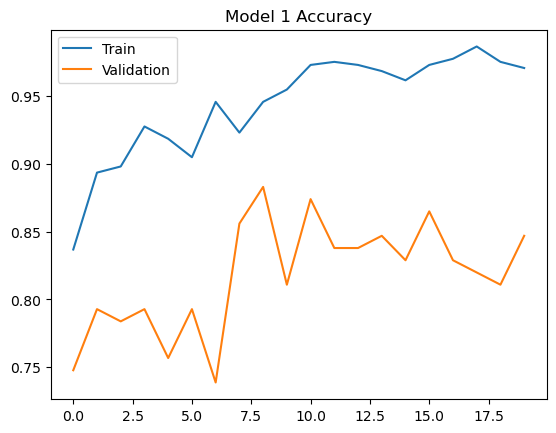

In [62]:
plt.plot(h1.history['accuracy'])
plt.plot(h1.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.title("Model 1 Accuracy")
plt.show()

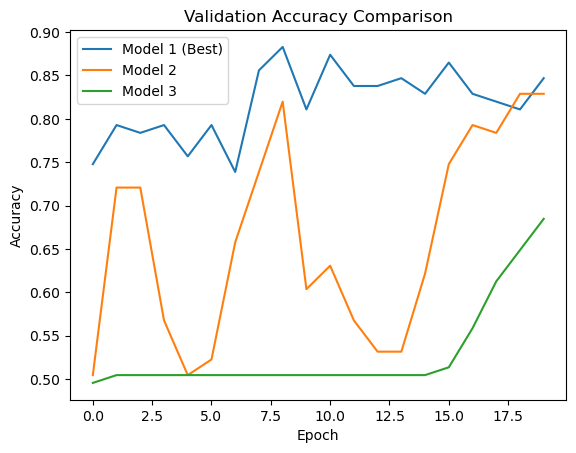

In [64]:
plt.plot(h1.history['val_accuracy'], label='Model 1 (Best)')
plt.plot(h2.history['val_accuracy'], label='Model 2')
plt.plot(h3.history['val_accuracy'], label='Model 3')

plt.legend()
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [75]:
def predict_signature(path):

    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (128,128))
    img = img / 255.0
    img = img.reshape(1,128,128,1)

    pred = model1.predict(img)

    if pred[0][0] > 0.5:
        print("Forged")
    else:
        print("Genuine")
predict_signature("C:/Users/tirth/Desktop/Practicals/DL(6thsem)/processed/forged/Forged_p5_10.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Forged


In [77]:
from tensorflow.keras.models import Model
from numpy.linalg import norm
model1.predict(np.zeros((1,128,128,1)))
feature_model = Model(inputs=model1.inputs, outputs=model1.layers[-2].output)

def compare_signatures(img1, img2):

    def process(img_path):
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (128,128))
        img = img / 255.0
        return img.reshape(1,128,128,1)

    f1 = feature_model.predict(process(img1))
    f2 = feature_model.predict(process(img2))

    similarity = np.dot(f1, f2.T) / (norm(f1) * norm(f2))

    print("Similarity Score:", similarity)

    if similarity > 0.8:
        print("Same person (Genuine)")
    else:
        print("Different (Forged)")
compare_signatures("C:/Users/tirth/Desktop/Practicals/DL(6thsem)/processed/genuine/Genuine_p5_10.png","C:/Users/tirth/Desktop/Practicals/DL(6thsem)/processed/forged/Forged_p5_10.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Similarity Score: [[0.45849007]]
Different (Forged)


In [78]:
model1.save("signature_model.keras")